# KND_04 — Step 7: Tune the models and choose an alert threshold

We predict whether an animal admission will last **more than 30 days**. Our approved data comes from [Sonoma County, California, USA](https://data.sonomacounty.ca.gov/Government/Animal-Shelter-Intake-and-Outcome/924a-vesw).

Notebook 6 compared four starting models. Here we compare a small, planned set of settings, try giving more importance to the less common class, choose an alert cutoff and check the scores. **Tuning may help or make results worse. We report both honestly.**

## Start here

1. Open this notebook in Colab.
2. Upload **KND_04_Step7_Input_Files.zip** in the Files panel. Keep its filename unchanged.
3. Run the cells in order. The ZIP extracts automatically. Earlier notebooks do not need to be rerun.

The bundle has **6,096 training** and **1,163 validation** records. It contains **no test records or labels**. The search runs 72 small model fits, followed by four full training fits; allow several minutes depending on your computer.

Libraries: pandas, numpy, scikit-learn, scipy, joblib and matplotlib. If needed, run `%pip install pandas numpy scikit-learn scipy joblib matplotlib` in a separate cell and restart the runtime. Exact versions for the checked run are in the bundle. Different versions can give slightly different results.

**Outputs:** a `step7_results` folder beside `step7_inputs`, usually `/content/step7_results` in Colab. Download the results ZIP at the end so the files survive a runtime reset.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import hashlib, importlib, json, shutil, sys, warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, scipy, joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (average_precision_score, roc_auc_score, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    brier_score_loss, confusion_matrix)
from threadpoolctl import threadpool_limits

needed = {"train_inputs.csv", "validation_inputs.csv", "train_labels_and_audit.csv",
          "validation_labels_and_audit.csv", "shelter_preprocessing.py",
          "requirements_step7.txt", "README.txt", "input_manifest.json", "step6_initial_results.csv"}
candidates = [Path("step7_inputs"), Path("outputs/step7_inputs"), Path("/content/step7_inputs")]
INPUT_DIR = next((p.resolve() for p in candidates if all((p / n).is_file() for n in needed)), None)
if INPUT_DIR is None:
    zip_name = "KND_04_Step7_Input_Files.zip"
    paths = [Path(zip_name), Path("outputs") / zip_name, Path("/content") / zip_name]
    zip_path = next((p.resolve() for p in paths if p.is_file()), None)
    if zip_path is None:
        raise FileNotFoundError("Upload KND_04_Step7_Input_Files.zip, then rerun this cell.")
    with ZipFile(zip_path) as archive:
        expected = {"step7_inputs/" + n for n in needed}
        assert set(archive.namelist()) == expected and len(archive.namelist()) == len(expected), "Use the matching Step 7 ZIP."
        archive.extractall(zip_path.parent)
    INPUT_DIR = zip_path.parent / "step7_inputs"
manifest = json.loads((INPUT_DIR / "input_manifest.json").read_text(encoding="utf-8"))
assert manifest["test_data_included"] is False
assert set(manifest["files_sha256"]) == needed - {"input_manifest.json"}
for name, expected_hash in manifest["files_sha256"].items():
    assert hashlib.sha256((INPUT_DIR / name).read_bytes()).hexdigest() == expected_hash, f"{name}: replace the complete bundle; do not skip this check."
RESULTS_DIR = INPUT_DIR.parent / "step7_results"
MODELS_DIR = RESULTS_DIR / "fitted_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(INPUT_DIR))
importlib.invalidate_caches()
sys.modules.pop("shelter_preprocessing", None)
import shelter_preprocessing as prep
assert prep.RAW_INPUT_FIELDS == manifest["raw_input_fields"]
print("Inputs:", INPUT_DIR)
print("Results:", RESULTS_DIR)
print("No test data is included or loaded.")

Inputs: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step7_inputs
Results: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step7_results
No test data is included or loaded.


## 1. Fix the rules before running the search

**Settings:** 3 choices for each of 4 model families, each with and without balanced weights = **24 candidates**. Every candidate gets the same three checks inside the training period.

**Balanced weights:** a long-stay record gets more influence when that class is less common. We calculate weights from the current training part only. We do not copy records or invent animals.

**Choose a model:** highest mean **average precision (AP)** across the three training checks. AP measures how well higher scores put real long stays near the top. It is not ordinary accuracy. Ties use lower variation across periods, then candidate name. Variation is not a confidence interval. We keep the best setting in each family for comparison, but lock the overall choice before looking at this notebook's external validation scores.

**Choose the alert cutoff later:** try 0.05, 0.10, ..., 0.95 on validation; choose the highest **F2**, then higher precision, then higher cutoff. F2 puts more emphasis on catching long stays than F1. This is our prototype study rule, not a cost or workload agreed with a shelter. We will show the false alerts it creates.

**Check score quality:** compare Brier error with a simple training-prior baseline and draw a reliability plot. We assess calibration; we do not fit a new calibrator on the validation answers and then claim independent success.

Validation was already used in Notebook 6. It remains development data. The separate test set is reserved for a later final check.

In [2]:
SEED = 42
FAMILIES = {
    "logistic_regression": (LogisticRegression, [
        {"C": c, "solver": "lbfgs", "max_iter": 2000} for c in [0.1, 1.0, 10.0]]),
    "decision_tree": (DecisionTreeClassifier, [
        {"max_depth": 3, "min_samples_leaf": 20},
        {"max_depth": 6, "min_samples_leaf": 10},
        {"max_depth": None, "min_samples_leaf": 30}]),
    "random_forest": (RandomForestClassifier, [
        {"n_estimators": 150, "max_depth": 8, "min_samples_leaf": 5, "max_features": "sqrt", "n_jobs": 1},
        {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt", "n_jobs": 1},
        {"n_estimators": 200, "max_depth": 12, "min_samples_leaf": 10, "max_features": "sqrt", "n_jobs": 1}]),
    "gradient_boosting": (GradientBoostingClassifier, [
        {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 10, "n_iter_no_change": None},
        {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3, "min_samples_leaf": 5, "n_iter_no_change": None},
        {"n_estimators": 150, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 20, "n_iter_no_change": None}])}
specs = []
for family, (_, settings) in FAMILIES.items():
    for i, params in enumerate(settings, 1):
        for balanced in [False, True]:
            specs.append({"candidate_id": f"{family}_{i}_{'balanced' if balanced else 'ordinary'}",
                          "family": family, "balanced": balanced, "params": dict(params, random_state=SEED)})
spec_by_id = {s["candidate_id"]: s for s in specs}
THRESHOLDS = np.round(np.arange(0.05, 0.951, 0.05), 2)
FOLD_WINDOWS = [("2024-01-01", "2024-07-01"), ("2024-07-01", "2025-01-01"), ("2025-01-01", "2025-05-31")]
settings = {"candidates": specs, "fold_windows": FOLD_WINDOWS, "gap_days": 31,
    "primary_metric": "mean_training_fold_average_precision", "threshold_grid": THRESHOLDS.tolist(),
    "threshold_selection": "validation F2, precision, threshold descending", "test_evaluated": False}
(RESULTS_DIR / "search_settings.json").write_text(json.dumps(settings, indent=2), encoding="utf-8")

def evaluate(y, score, threshold=0.5):
    y, score = np.asarray(y), np.asarray(score)
    assert np.isfinite(score).all() and ((score >= 0) & (score <= 1)).all()
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"average_precision": float(average_precision_score(y, score)),
        "roc_auc": float(roc_auc_score(y, score)), "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)), "f1": float(f1_score(y, pred, zero_division=0)),
        "f2": float(fbeta_score(y, pred, beta=2, zero_division=0)),
        "accuracy": float(accuracy_score(y, pred)), "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "brier_score": float(brier_score_loss(y, score)), "true_short": int(tn), "false_alerts": int(fp),
        "missed_long_stays": int(fn), "caught_long_stays": int(tp), "alert_fraction": float(pred.mean())}

def fit_candidate(spec, X, y):
    estimator = FAMILIES[spec["family"]][0](**spec["params"])
    pipeline = Pipeline([("preprocess", prep.make_preprocessor(rare_min_count=10)), ("model", estimator)])
    kwargs = {}
    if spec["balanced"]:
        weights = compute_sample_weight("balanced", y)
        assert np.isfinite(weights).all() and np.isclose(weights[y == 0].sum(), weights[y == 1].sum())
        kwargs["model__sample_weight"] = weights
    with warnings.catch_warnings(), threadpool_limits(limits=1):
        warnings.simplefilter("error", ConvergenceWarning)
        pipeline.fit(X, y, **kwargs)
    assert pipeline.named_steps["preprocess"].named_steps["features"].fit_rows_ == len(X)
    return pipeline

def scores_for(model, X):
    position = int(np.flatnonzero(model.named_steps["model"].classes_ == 1)[0])
    with threadpool_limits(limits=1):
        return model.predict_proba(X)[:, position]
print("Planned candidates:", len(specs), "| training checks:", len(FOLD_WINDOWS))

Planned candidates: 24 | training checks: 3


## 2. Make three smaller time-based checks inside training

For example, in the first check we learn from earlier records and predict admissions from January–June 2024. A **31-day gap** helps ensure a long-stay answer could be known before the next period. We also check the actual label-known date.

If an animal appears in the later checking period, its earlier admissions are removed from that check's fitting data. This prevents the same animal appearing on both sides. We save the row membership so this can be audited.

The training window grows for each check. Earlier checking records can join a later fitting window when eligible. This does not change the original train/validation/test files. Every fit learns its own imputation values, categories and scaling from its own fitting rows.

In [3]:
X_train = pd.read_csv(INPUT_DIR / "train_inputs.csv")
train_audit = pd.read_csv(INPUT_DIR / "train_labels_and_audit.csv", dtype={"id": "string"})
y_train = train_audit["long_stay_30"].to_numpy(dtype=int)
assert len(X_train) == len(train_audit) == manifest["expected_training_rows"] == 6096
assert list(X_train.columns) == prep.RAW_INPUT_FIELDS
assert train_audit["source_row_number"].is_unique and train_audit["id"].notna().all()
dates = pd.to_datetime(train_audit["intake_date"])
known = pd.to_datetime(train_audit["label_known_date"])
assert dates.equals(pd.to_datetime(X_train["intake_date"]))
assert (dates < pd.Timestamp(manifest["training_end_exclusive"])).all()
assert (known < pd.Timestamp(manifest["validation_start"])).all()
folds, fold_rows, membership = [], [], []
for fold_id, (start_text, end_text) in enumerate(FOLD_WINDOWS, 1):
    start, end = pd.Timestamp(start_text), pd.Timestamp(end_text)
    gap_start = start - pd.Timedelta(days=31)
    check_mask = dates.ge(start) & dates.lt(end)
    time_eligible = dates.lt(gap_start) & known.lt(start)
    fit_mask = time_eligible & ~train_audit["id"].isin(train_audit.loc[check_mask, "id"])
    fit_idx, check_idx = np.flatnonzero(fit_mask), np.flatnonzero(check_mask)
    assert len(fit_idx) and len(check_idx)
    assert set(train_audit.iloc[fit_idx]["id"]).isdisjoint(train_audit.iloc[check_idx]["id"])
    assert set(np.unique(y_train[fit_idx])) == set(np.unique(y_train[check_idx])) == {0, 1}
    assert dates.iloc[fit_idx].max() < gap_start and known.iloc[fit_idx].max() < start
    folds.append((fit_idx, check_idx))
    fold_rows.append({"fold": fold_id, "fit_rows": len(fit_idx), "check_rows": len(check_idx),
        "fit_end_exclusive": str(gap_start.date()), "check_start": start_text, "check_end_exclusive": end_text,
        "earlier_same_animal_rows_removed": int(time_eligible.sum() - fit_mask.sum()),
        "fit_long_share": y_train[fit_idx].mean(), "check_long_share": y_train[check_idx].mean()})
    for role, indices in [("fit", fit_idx), ("check", check_idx)]:
        frame = train_audit.iloc[indices][["source_row_number", "id", "intake_date", "label_known_date", "long_stay_30"]].copy()
        frame.insert(0, "role", role)
        frame.insert(0, "fold", fold_id)
        membership.append(frame)
fold_summary = pd.DataFrame(fold_rows)
fold_summary.to_csv(RESULTS_DIR / "cv_fold_summary.csv", index=False)
pd.concat(membership, ignore_index=True).to_csv(RESULTS_DIR / "cv_fold_membership.csv", index=False)
print(fold_summary.to_string(index=False))

 fold  fit_rows  check_rows fit_end_exclusive check_start check_end_exclusive  earlier_same_animal_rows_removed  fit_long_share  check_long_share
    1      2297        1231        2023-12-01  2024-01-01          2024-07-01                                48        0.324336          0.326564
    2      3508        1314        2024-05-31  2024-07-01          2025-01-01                                67        0.325542          0.357686
    3      4806        1003        2024-12-01  2025-01-01          2025-05-31                                85        0.335206          0.209372


## 3. Run the planned search

This is the longest cell. One line appears after each candidate finishes all three checks. Do not replace poor results with a different search after seeing the final test set.

01/24 finished: logistic_regression_1_ordinary
02/24 finished: logistic_regression_1_balanced
03/24 finished: logistic_regression_2_ordinary
04/24 finished: logistic_regression_2_balanced
05/24 finished: logistic_regression_3_ordinary
06/24 finished: logistic_regression_3_balanced
07/24 finished: decision_tree_1_ordinary
08/24 finished: decision_tree_1_balanced
09/24 finished: decision_tree_2_ordinary
10/24 finished: decision_tree_2_balanced
11/24 finished: decision_tree_3_ordinary
12/24 finished: decision_tree_3_balanced
13/24 finished: random_forest_1_ordinary
14/24 finished: random_forest_1_balanced
15/24 finished: random_forest_2_ordinary
16/24 finished: random_forest_2_balanced
17/24 finished: random_forest_3_ordinary
18/24 finished: random_forest_3_balanced
19/24 finished: gradient_boosting_1_ordinary
20/24 finished: gradient_boosting_1_balanced
21/24 finished: gradient_boosting_2_ordinary
22/24 finished: gradient_boosting_2_balanced
23/24 finished: gradient_boosting_3_ordinary
2

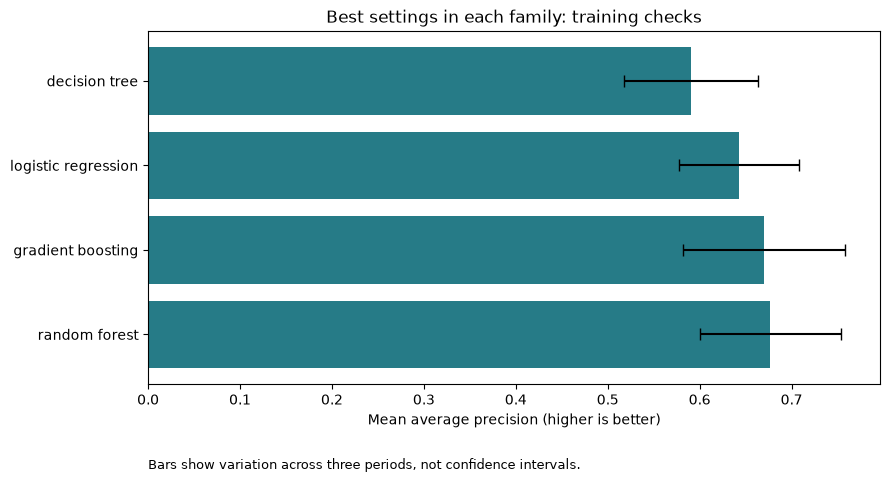

In [4]:
cv_rows = []
for n, spec in enumerate(specs, 1):
    for fold_id, (fit_idx, check_idx) in enumerate(folds, 1):
        pipeline = fit_candidate(spec, X_train.iloc[fit_idx], y_train[fit_idx])
        score = scores_for(pipeline, X_train.iloc[check_idx])
        row = {"candidate_id": spec["candidate_id"], "family": spec["family"], "balanced": spec["balanced"],
               "fold": fold_id, **evaluate(y_train[check_idx], score)}
        row["fit_average_precision"] = float(average_precision_score(y_train[fit_idx], scores_for(pipeline, X_train.iloc[fit_idx])))
        cv_rows.append(row)
    print(f"{n:02d}/24 finished: {spec['candidate_id']}")
cv_results = pd.DataFrame(cv_rows)
assert len(cv_results) == 72
cv_summary = cv_results.groupby(["candidate_id", "family", "balanced"], as_index=False).agg(
    mean_ap=("average_precision", "mean"), std_ap=("average_precision", "std"),
    mean_fit_ap=("fit_average_precision", "mean"), mean_recall=("recall", "mean"), mean_brier=("brier_score", "mean"))
cv_summary = cv_summary.sort_values(["mean_ap", "std_ap", "candidate_id"], ascending=[False, True, True]).reset_index(drop=True)
cv_summary.insert(0, "rank", np.arange(1, len(cv_summary) + 1))
cv_summary["parameters"] = cv_summary.candidate_id.map(lambda key: json.dumps(spec_by_id[key]["params"], sort_keys=True))
family_winners = cv_summary.drop_duplicates("family").copy()
selected_id = str(cv_summary.iloc[0].candidate_id)
selected_spec = spec_by_id[selected_id]
cv_results.to_csv(RESULTS_DIR / "cv_results.csv", index=False)
cv_summary.to_csv(RESULTS_DIR / "cv_summary.csv", index=False)
(RESULTS_DIR / "model_choice_before_validation.json").write_text(json.dumps({
    "selected_candidate": selected_spec, "selection_basis": "training folds only", "mean_cv_ap": float(cv_summary.iloc[0].mean_ap),
    "test_evaluated": False}, indent=2), encoding="utf-8")
print("\nSelected using training checks:", selected_id)
print(family_winners[["family", "candidate_id", "mean_ap", "std_ap"]].to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(family_winners.family.str.replace("_", " "), family_winners.mean_ap, xerr=family_winners.std_ap, color="#267b87", capsize=4)
ax.set(xlabel="Mean average precision (higher is better)", title="Best settings in each family: training checks")
ax.text(0, -0.24, "Bars show variation across three periods, not confidence intervals.", transform=ax.transAxes, fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "01_training_cv.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 4. Fit the family winners and compare on external validation

We now load the 1,163 later validation records. Each family's chosen settings are fitted again using all 6,096 training records. We compare them with the matching starting model from Notebook 6. **We keep the model choice made above even if another model looks better here.**

The baseline gives every animal the training long-stay share as its score. At 0.50 it predicts short stays for everyone. Its accuracy can look high while catching no long stays.

             family  selected_by_cv  initial_validation_ap  average_precision  ap_change_from_step6  recall  false_alerts  missed_long_stays
      random_forest            True                 0.3585             0.3585                0.0000  0.4286           200                140
  gradient_boosting           False                 0.3672             0.3718                0.0045  0.6980           331                 74
logistic_regression           False                 0.3496             0.3513                0.0017  0.4082           183                145
      decision_tree           False                 0.2894             0.3397                0.0503  0.5878           261                101
           baseline           False                 0.2107             0.2107                0.0000  0.0000             0                245
Training long-stay share: 0.3136 | validation: 0.2107


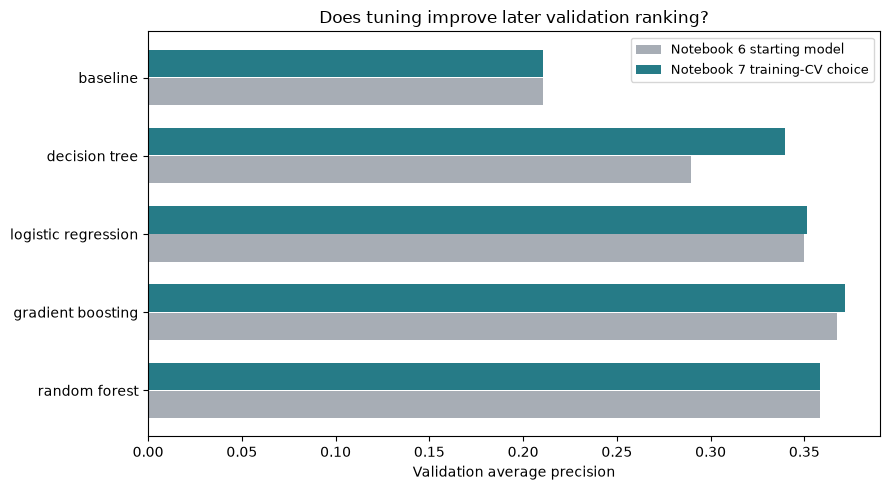

In [5]:
X_validation = pd.read_csv(INPUT_DIR / "validation_inputs.csv")
validation_audit = pd.read_csv(INPUT_DIR / "validation_labels_and_audit.csv", dtype={"id": "string"})
y_validation = validation_audit["long_stay_30"].to_numpy(dtype=int)
assert len(X_validation) == len(validation_audit) == manifest["expected_validation_rows"] == 1163
assert list(X_validation.columns) == prep.RAW_INPUT_FIELDS
assert validation_audit["source_row_number"].is_unique and validation_audit["id"].notna().all()
assert set(train_audit.id).isdisjoint(validation_audit.id)
assert set(train_audit.source_row_number).isdisjoint(validation_audit.source_row_number)
vdates = pd.to_datetime(validation_audit.intake_date)
assert vdates.equals(pd.to_datetime(X_validation.intake_date))
assert vdates.ge(pd.Timestamp(manifest["validation_start"])).all()
assert vdates.lt(pd.Timestamp(manifest["validation_end_exclusive"])).all()
assert pd.to_datetime(validation_audit.label_known_date).lt(pd.Timestamp(manifest["test_start"])).all()
assert set(np.unique(y_validation)) == {0, 1}
initial = pd.read_csv(INPUT_DIR / "step6_initial_results.csv").set_index("model_key")
models, validation_scores, comparison_rows = {}, {}, []
for key in family_winners.candidate_id:
    spec = spec_by_id[key]
    pipeline = fit_candidate(spec, X_train, y_train)
    assert pipeline.named_steps["preprocess"].transform(X_train.head(2)).shape[1] == manifest["expected_encoded_features"]
    score = scores_for(pipeline, X_validation)
    models[key], validation_scores[key] = pipeline, score
    joblib.dump(pipeline, MODELS_DIR / f"{key}.joblib")
    metrics = evaluate(y_validation, score)
    comparison_rows.append({"candidate_id": key, "family": spec["family"], "selected_by_cv": key == selected_id,
        "initial_validation_ap": float(initial.loc[spec["family"], "validation_average_precision"]), **metrics})
baseline_score = np.full(len(y_validation), y_train.mean())
baseline_metrics = evaluate(y_validation, baseline_score)
comparison_rows.append({"candidate_id": "training_prior_baseline", "family": "baseline", "selected_by_cv": False,
    "initial_validation_ap": float(initial.loc["baseline", "validation_average_precision"]), **baseline_metrics})
comparison = pd.DataFrame(comparison_rows)
comparison["ap_change_from_step6"] = comparison.average_precision - comparison.initial_validation_ap
comparison.to_csv(RESULTS_DIR / "validation_comparison.csv", index=False)
print(comparison[["family", "selected_by_cv", "initial_validation_ap", "average_precision", "ap_change_from_step6", "recall", "false_alerts", "missed_long_stays"]].round(4).to_string(index=False))
print("Training long-stay share:", round(y_train.mean(), 4), "| validation:", round(y_validation.mean(), 4))
fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(len(comparison))
ax.barh(positions - .18, comparison.initial_validation_ap, height=.35, label="Notebook 6 starting model", color="#a7adb5")
ax.barh(positions + .18, comparison.average_precision, height=.35, label="Notebook 7 training-CV choice", color="#267b87")
ax.set_yticks(positions, comparison.family.str.replace("_", " "))
ax.set(xlabel="Validation average precision", title="Does tuning improve later validation ranking?")
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS_DIR / "02_validation_comparison.png", dpi=150)
plt.show(); plt.close(fig)

## 5. Choose the alert threshold for the selected model

Example: with a cutoff of 0.30, a score of 0.36 triggers an alert; a score of 0.22 does not. Lower cutoffs usually catch more long stays but create more false alerts.

We use the F2 rule set earlier. **This does not change the model or its AP.** It only changes which scores become alerts. We report the fraction of all animals flagged so the extra workload is visible. Results used to pick the cutoff are development results, not an independent final score.

Selected candidate: random_forest_2_ordinary
          rule  precision  recall     f2  alert_fraction  caught_long_stays  missed_long_stays  false_alerts
  default 0.50     0.3443  0.4286 0.4086          0.2623                105                140           200
   chosen 0.20     0.2678  0.9061 0.6136          0.7128                222                 23           607
alert everyone     0.2107  1.0000 0.5716          1.0000                245                  0           918
  alert nobody     0.0000  0.0000 0.0000          0.0000                  0                245             0
Chosen rule flags 71.3% of arrivals. This workload needs shelter feedback.


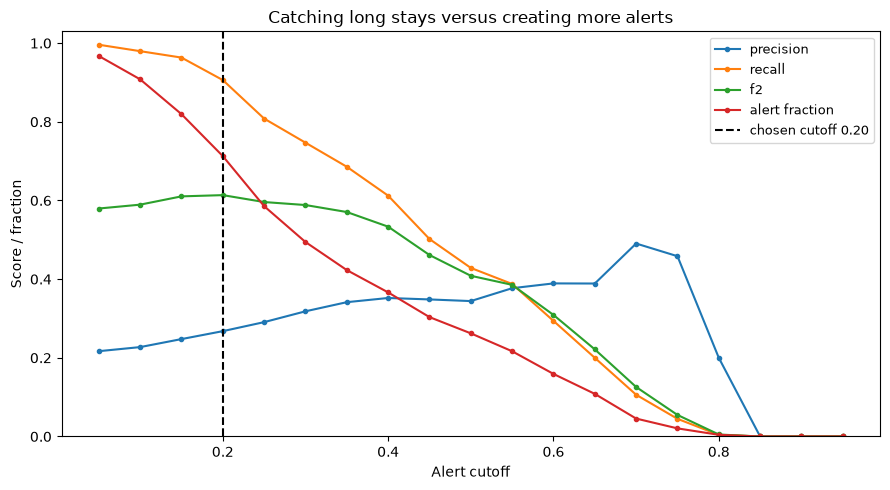

In [6]:
selected_score = validation_scores[selected_id]
thresholds = pd.DataFrame([{"threshold": float(t), **evaluate(y_validation, selected_score, t)} for t in THRESHOLDS])
chosen = thresholds.sort_values(["f2", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
chosen_threshold = float(chosen.threshold)
thresholds["selected"] = np.isclose(thresholds.threshold, chosen_threshold)
thresholds.to_csv(RESULTS_DIR / "threshold_comparison.csv", index=False)
default_metrics = evaluate(y_validation, selected_score, 0.5)
chosen_metrics = evaluate(y_validation, selected_score, chosen_threshold)
reference_rows = [
    {"rule": "default 0.50", **default_metrics},
    {"rule": f"chosen {chosen_threshold:.2f}", **chosen_metrics},
    {"rule": "alert everyone", **evaluate(y_validation, selected_score, 0.0)},
    {"rule": "alert nobody", **evaluate(y_validation, selected_score, 1.01)}]
references = pd.DataFrame(reference_rows)
references.to_csv(RESULTS_DIR / "alert_rule_comparison.csv", index=False)
print("Selected candidate:", selected_id)
print(references[["rule", "precision", "recall", "f2", "alert_fraction", "caught_long_stays", "missed_long_stays", "false_alerts"]].round(4).to_string(index=False))
print(f"Chosen rule flags {chosen_metrics['alert_fraction']:.1%} of arrivals. This workload needs shelter feedback.")
fig, ax = plt.subplots(figsize=(9, 5))
for field in ["precision", "recall", "f2", "alert_fraction"]:
    ax.plot(thresholds.threshold, thresholds[field], marker=".", label=field.replace("_", " "))
ax.axvline(chosen_threshold, color="black", linestyle="--", label=f"chosen cutoff {chosen_threshold:.2f}")
ax.set(xlabel="Alert cutoff", ylabel="Score / fraction", ylim=(0, 1.03), title="Catching long stays versus creating more alerts")
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS_DIR / "03_threshold_tradeoff.png", dpi=150)
plt.show(); plt.close(fig)

## 6. Check whether the scores match observed outcomes

If animals scoring around 0.60 really had about 60% long stays, their scores would match outcomes well in that group. We compare mean scores with the actual long-stay share in five score bands.

A lower **Brier score** means smaller probability errors; it reflects both ranking and calibration, so it is not a pure calibration measure. Small bins and this one validation period limit the conclusions. Balanced training weights can change the score scale.

We have **not fitted a probability calibrator**. Treat outputs as model scores until stronger evidence supports probability claims.

   score_band  count  mean_score  observed_long_share
(-0.001, 0.2]    334      0.1237               0.0689
   (0.2, 0.4]    403      0.2824               0.1787
   (0.4, 0.6]    241      0.4979               0.3237
   (0.6, 0.8]    180      0.6765               0.3944
   (0.8, 1.0]      5      0.8162               0.2000
Selected-model Brier error: 0.1780
Training-prior baseline error: 0.1769
Lower error than baseline: False


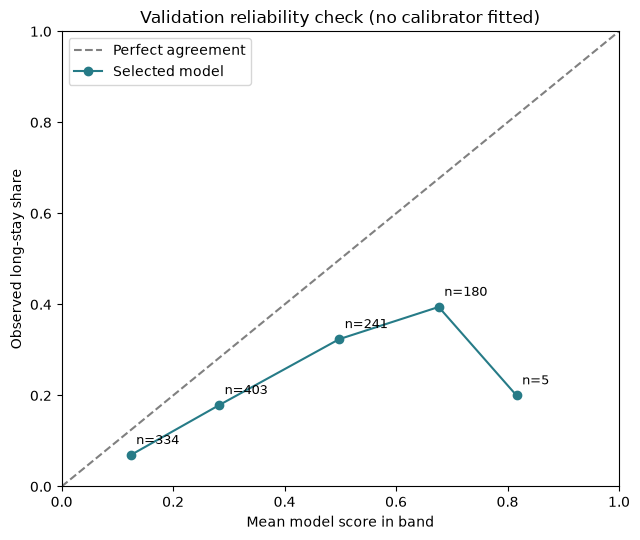

In [7]:
calibration = pd.DataFrame({"score": selected_score, "actual": y_validation})
calibration["score_band"] = pd.cut(calibration.score, bins=np.linspace(0, 1, 6), include_lowest=True)
calibration_bins = calibration.groupby("score_band", observed=False).agg(
    count=("actual", "size"), mean_score=("score", "mean"), observed_long_share=("actual", "mean")).reset_index()
calibration_bins.to_csv(RESULTS_DIR / "calibration_bins.csv", index=False)
print(calibration_bins.round(4).to_string(index=False))
print(f"Selected-model Brier error: {chosen_metrics['brier_score']:.4f}")
print(f"Training-prior baseline error: {baseline_metrics['brier_score']:.4f}")
print("Lower error than baseline:", chosen_metrics["brier_score"] < baseline_metrics["brier_score"])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
shown = calibration_bins.loc[calibration_bins["count"].gt(0)]
ax.plot([0, 1], [0, 1], "--", color="grey", label="Perfect agreement")
ax.plot(shown.mean_score, shown.observed_long_share, "o-", color="#267b87", label="Selected model")
for row in shown.itertuples():
    ax.annotate(f"n={row.count}", (row.mean_score, row.observed_long_share), xytext=(4, 8), textcoords="offset points", fontsize=9)
ax.set(xlabel="Mean model score in band", ylabel="Observed long-stay share", xlim=(0, 1), ylim=(0, 1), title="Validation reliability check (no calibrator fitted)")
ax.legend(); fig.tight_layout(); fig.savefig(RESULTS_DIR / "04_reliability.png", dpi=150)
plt.show(); plt.close(fig)

## 7. Save the frozen model and its alert rule

The model and cutoff belong together. The saved pipeline includes preprocessing. Calling `.predict()` uses the classifier's default decision rule, **not our chosen cutoff**. Use `.predict_proba()` and compare the long-stay score with `selection_policy.json` instead.

The next notebook must use this frozen choice on the reserved test data. If test performance disappoints, report that result. Retuning on those test answers would make it development data and require another independent final check.

In [8]:
shutil.copyfile(INPUT_DIR / "shelter_preprocessing.py", RESULTS_DIR / "shelter_preprocessing.py")
versions = {"pandas": pd.__version__, "numpy": np.__version__, "scikit-learn": sklearn.__version__,
            "scipy": scipy.__version__, "joblib": joblib.__version__, "matplotlib": plt.matplotlib.__version__}
(RESULTS_DIR / "requirements_modeling.txt").write_text("\n".join(f"{k}=={v}" for k, v in versions.items()) + "\n", encoding="utf-8")
joblib.dump(models[selected_id], RESULTS_DIR / "selected_model.joblib")
predictions = validation_audit[["source_row_number", "id", "intake_date", "long_stay_30"]].copy()
for key, score in validation_scores.items():
    predictions[key + "_score"] = score
predictions["selected_long_stay_score"] = selected_score
predictions["selected_alert"] = (selected_score >= chosen_threshold).astype(int)
predictions.to_csv(RESULTS_DIR / "validation_predictions.csv", index=False)
policy = {"candidate": selected_spec, "alert_threshold": chosen_threshold, "positive_class": 1,
    "target": "long_stay_30", "target_definition": "stay longer than 30 days",
    "model_selection": "mean AP across three training-only temporal folds",
    "threshold_selection": "maximum validation F2; ties: precision then higher cutoff",
    "fit_rows": len(X_train), "validation_rows": len(X_validation), "raw_input_fields": prep.RAW_INPUT_FIELDS,
    "probabilities_calibrated": False, "calibration_assessed": True, "test_evaluated": False,
    "model_sha256": hashlib.sha256((RESULTS_DIR / "selected_model.joblib").read_bytes()).hexdigest(),
    "helper_sha256": hashlib.sha256((RESULTS_DIR / "shelter_preprocessing.py").read_bytes()).hexdigest(),
    "versions": versions, "created_utc": datetime.now(timezone.utc).isoformat()}
(RESULTS_DIR / "selection_policy.json").write_text(json.dumps(policy, indent=2), encoding="utf-8")
selected_comparison = comparison.loc[comparison.candidate_id.eq(selected_id)].iloc[0]
notes = {"selected_candidate": selected_id, "selected_threshold": chosen_threshold,
    "cv_mean_ap": float(cv_summary.iloc[0].mean_ap),
    "validation_ap_change_from_same_family_step6": float(selected_comparison.ap_change_from_step6),
    "validation_default": default_metrics, "validation_chosen_cutoff": chosen_metrics, "validation_baseline": baseline_metrics,
    "input_hashes": manifest["files_sha256"], "test_evaluated": False,
    "limitations": ["Validation reused for development; threshold metrics are selected on these answers.",
        "Only three historical folds and one later validation period; not a confidence interval.",
        "One US county; no claim of transfer to Sri Lanka or other shelters.",
        "Assumed ongoing-stay labels and mutable attribute timing remain limitations.",
        "F2 is a study choice, not shelter-approved costs or workload.",
        "No probability calibrator fitted; no deployment or welfare benefit established."]}
(RESULTS_DIR / "tuning_notes.json").write_text(json.dumps(notes, indent=2), encoding="utf-8")
(RESULTS_DIR / "README.txt").write_text("""KND_04 Step 7: frozen candidate for final testing, not deployment approval.

Keep this folder, helper module, model and policy together. Use the recorded
requirements for reload. Never load untrusted joblib/pickle files.

Reload our own saved pipeline:
    from pathlib import Path
    import sys, json, joblib
    folder = Path('step7_results').resolve()
    sys.path.insert(0, str(folder))
    model = joblib.load(folder / 'selected_model.joblib')
    policy = json.loads((folder / 'selection_policy.json').read_text())
    classes = list(model.named_steps['model'].classes_)
    scores = model.predict_proba(new_arrival_dataframe)[:, classes.index(1)]
    alerts = (scores >= policy['alert_threshold']).astype(int)

Provide the ten raw fields listed in the policy. Do not use pipeline.predict()
to apply the chosen alert threshold: it uses the default classifier rule.
No test records were loaded here. Evaluate the frozen model and policy on the
reserved test set once, using a later notebook. Do not change the policy based
on test answers. Do not refit after locking without repeating and versioning
the selection process. A fresh weighted fit needs weights recomputed from
that fitting subset, as fit_candidate does; raw pipeline.fit alone will not
infer those weights. Model scores have not been probability-calibrated.
""", encoding="utf-8")
print("Saved model, policy, predictions, checks, plots and notes.")

Saved model, policy, predictions, checks, plots and notes.


## 8. Verify and package the results

We reload the saved models and check their scores, counts and original file fingerprints. The ZIP includes everything in `step7_results`. In Colab, right-click **KND_04_Step7_Results.zip** in the Files panel and choose Download.

In [9]:
assert len(models) == 4 and len(cv_summary) == 24 and len(cv_results) == 72
assert selected_id == cv_summary.iloc[0].candidate_id
assert thresholds.selected.sum() == 1
assert np.isclose(chosen_metrics["average_precision"], default_metrics["average_precision"])
for key, expected_scores in validation_scores.items():
    restored = joblib.load(MODELS_DIR / f"{key}.joblib")
    np.testing.assert_allclose(scores_for(restored, X_validation), expected_scores, rtol=1e-10, atol=1e-12)
    row = comparison.loc[comparison.candidate_id.eq(key)].iloc[0]
    assert sum(int(row[k]) for k in ["true_short", "false_alerts", "missed_long_stays", "caught_long_stays"]) == len(y_validation)
restored = joblib.load(RESULTS_DIR / "selected_model.joblib")
np.testing.assert_allclose(scores_for(restored, X_validation), selected_score, rtol=1e-10, atol=1e-12)
for name, expected_hash in manifest["files_sha256"].items():
    assert hashlib.sha256((INPUT_DIR / name).read_bytes()).hexdigest() == expected_hash
assert baseline_metrics["recall"] == 0
assert np.isclose(baseline_metrics["average_precision"], y_validation.mean())
assert calibration_bins["count"].sum() == len(y_validation)
result_zip = shutil.make_archive(str(RESULTS_DIR.parent / "KND_04_Step7_Results"), "zip", root_dir=RESULTS_DIR.parent, base_dir=RESULTS_DIR.name)
print("All saved-model, count and input checks passed.")
print("Download this results ZIP:", result_zip)
print("Selected:", selected_id, "| alert cutoff:", chosen_threshold)
print(f"Validation AP change from its Step 6 family: {selected_comparison.ap_change_from_step6:+.4f}")
print(f"Chosen cutoff: caught {chosen_metrics['caught_long_stays']}, missed {chosen_metrics['missed_long_stays']}, false alerts {chosen_metrics['false_alerts']}.")
print("The test set remains untouched.")

All saved-model, count and input checks passed.
Download this results ZIP: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\KND_04_Step7_Results.zip
Selected: random_forest_2_ordinary | alert cutoff: 0.2
Validation AP change from its Step 6 family: +0.0000
Chosen cutoff: caught 222, missed 23, false alerts 607.
The test set remains untouched.


## Simple viva explanation

"We tried a small set of settings for our four algorithms. We tested them on three later periods inside the training data, keeping 31-day gaps and separating animal IDs. Each fit learned preprocessing only from its own training rows. We also tried balanced weights so long stays had more influence.

We chose the model using average precision from those training checks. Then we used validation to choose an alert cutoff using F2. We checked how many long stays we caught, how many we missed and how many false alerts we created. We also checked whether the scores matched actual outcomes. We saved the model and cutoff together. The final test set has not been used yet."

**Share the work:** Member 1 explains the time-based folds and leakage checks; Member 2 explains model settings and weights; Member 3 explains cutoff selection, missed cases and false alerts; Member 4 explains calibration checks, saving and limitations. Everyone should run and understand the complete notebook. Describe only work each person actually did.

**Fill in from your run:** selected model __; mean training-check AP __; validation AP __; chosen cutoff __; missed long stays __; false alerts __. Say if tuning was worse than the starting model. Do not describe selected validation scores as final test results.

## Next: Notebook 8 — final test evaluation

Use the frozen model and cutoff on the reserved test set. Afterwards, interpret errors and explanations, finish any separately required data-mining work, build the user interface and complete the report/presentation. This notebook does not finish those project stages.

References: [balanced sample weights](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html), [F-beta/F2](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html), [probability calibration and Brier limitations](https://scikit-learn.org/stable/modules/calibration.html).